# 07 - Experimento Var3: Eliminacion de Features Colineales

**Proyecto:** Deteccion de Riesgos de Corrupcion en Obras Publicas
**Sprint:** 3 - Resolucion de colinealidad

## SItuación del Experimento

El notebook 06 revelo:
1. **Colinealidad severa:** 18 features con VIF > 10. corr(ofertado_mean, ofertado_prom_mean) = 1.0
2. **SHAP inesperado:** features de montos no aparecen en top SHAP clase 3. El comite las domina.
**Hipotesis:** la colinealidad aplasta las senales de montos entre si.

## Pregunta
> Si eliminamos features redundantes (1 representante por grupo),
> emergen las senales de colusion en SHAP? Mejora el Macro F1?

## Diseño

| Grupo | Eliminadas | Conservada |
|-------|-----------|----------|
| Montos | 8 (corr hasta 1.0) | obra_monto_contractual_sum |
| N postores | 5 (VIF=inf) | obra_n_participantes_mean |
| Comite | 2 (VIF=inf) | obra_ratio_repeticion_comite |
| N ofertas | 1 (VIF=inf) | obra_rango_ofertas |


---
## PASO 0 - Imports

In [1]:
from pathlib import Path
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('pip install shap')

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    VIF_OK = True
except ImportError:
    VIF_OK = False

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

BASE_DIR  = Path(r'C:\IA_Investigacion\Deteccion_Corrupcion')
DATA_PROC = BASE_DIR / 'data' / 'processed'
FIG_DIR   = BASE_DIR / 'reports' / 'figures'
LOG_DIR   = BASE_DIR / 'logs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS     = 5
ETIQUETAS    = {0:'Sin Riesgo', 1:'Bajamente Riesgosa',
                2:'Med/Alt Riesgosa', 3:'Extrem. Riesgosa'}
CLASS_LABELS = [ETIQUETAS[i] for i in sorted(ETIQUETAS)]
print('OK config')


OK config


c:\IA_Investigacion\Deteccion_Corrupcion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## PASO 1 - Carga y split

In [2]:
df = pd.read_parquet(DATA_PROC / 'dataset_obra_v4_model.parquet')

TARGET  = 'y_riesgo_obra'
EXCLUIR = ['IDENTIFICADOR_OBRA', 'RIESGO_OBRA', 'RIESGO_DESCRIPCION_OBRA']

X_full = df.drop(columns=[c for c in EXCLUIR + [TARGET] if c in df.columns])
y      = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Dataset : {X_full.shape[0]} obs x {X_full.shape[1]} features')
print(f'Train   : {X_train.shape[0]} | Test: {X_test.shape[0]}')


Dataset : 326 obs x 77 features
Train   : 260 | Test: 66


---
## PASO 2 - Features colineales a eliminar

In [3]:
ELIMINAR_COLINEALES = [
    # Grupo montos (corr hasta 1.0) -> conservar obra_monto_contractual_sum
    'obra_monto_ofertado_mean',
    'obra_monto_ofertado_prom_mean',
    'obra_monto_ofertado_min',
    'obra_monto_ofertado_max',
    'obra_monto_ganador_mean',
    'obra_monto_referencial_sum',
    'obra_ahorro_absoluto',
    'obra_monto_ofertado_std',
    # Grupo n postores (VIF=inf) -> conservar obra_n_participantes_mean
    'obra_n_participaciones',
    'obra_n_rucs_participantes',
    'obra_n_postores_mean',
    'obra_n_postores_min',
    'obra_n_postores_max',
    # Grupo comite (VIF=inf) -> conservar obra_ratio_repeticion_comite
    'obra_n_dnis_comite_unicos',
    'obra_n_miembros_comite',
    # Grupo n ofertas (VIF=inf) -> conservar obra_rango_ofertas
    'obra_n_ofertas',
]

ELIMINAR_REAL = [c for c in ELIMINAR_COLINEALES if c in X_full.columns]
NO_EXISTEN    = [c for c in ELIMINAR_COLINEALES if c not in X_full.columns]

print(f'Definidas   : {len(ELIMINAR_COLINEALES)}')
print(f'En dataset  : {len(ELIMINAR_REAL)}')
print(f'No existen  : {len(NO_EXISTEN)}')
for f in NO_EXISTEN:
    print(f'  - {f}')
print(f'Dataset resultante: {X_full.shape[1]} - {len(ELIMINAR_REAL)} = {X_full.shape[1]-len(ELIMINAR_REAL)} features')


Definidas   : 16
En dataset  : 16
No existen  : 0
Dataset resultante: 77 - 16 = 61 features


---
## PASO 3 - Dataset Var3 y verificacion de colinealidad

In [4]:
X_train_v3 = X_train.drop(columns=ELIMINAR_REAL, errors='ignore')
X_test_v3  = X_test.drop(columns=ELIMINAR_REAL,  errors='ignore')

print(f'Baseline : {X_train.shape[1]} features')
print(f'Var3     : {X_train_v3.shape[1]} features')
print(f'Eliminadas: {X_train.shape[1] - X_train_v3.shape[1]}')

# Verificar correlacion post-eliminacion en montos
montos_rest = [c for c in X_train_v3.select_dtypes(include=['number']).columns
               if any(k in c.lower() for k in ['monto','ofertado','contractual'])]
print(f'Features de montos restantes ({len(montos_rest)}):')
for f in montos_rest:
    print(f'  {f}')

if len(montos_rest) > 1:
    corr_post = X_train_v3[montos_rest].corr()
    altos = [(corr_post.columns[i], corr_post.columns[j],
              round(abs(corr_post.iloc[i,j]),3))
             for i in range(len(corr_post.columns))
             for j in range(i+1, len(corr_post.columns))
             if abs(corr_post.iloc[i,j]) > 0.85]
    if altos:
        print('Pares con corr > 0.85 aun existentes:')
        for a, b, v in altos:
            print(f'  {a} - {b}: {v}')
    else:
        print('OK Colinealidad de montos resuelta')


Baseline : 77 features
Var3     : 61 features
Eliminadas: 16
Features de montos restantes (5):
  obra_monto_contractual_sum
  obra_ratio_contractual_referencial
  obra_n_contratos_montos_identicos
  obra_n_contratos_con_montos
  obra_pct_montos_identicos
Pares con corr > 0.85 aun existentes:
  obra_n_contratos_montos_identicos - obra_pct_montos_identicos: 1.0


---
## PASO 4 - Pipelines

In [5]:
def make_prep(X_ref):
    num_cols = X_ref.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_ref.select_dtypes(include=['object','category','bool']).columns.tolist()
    return ColumnTransformer([
        ('num', Pipeline([('i', SimpleImputer(strategy='median')),
                          ('s', StandardScaler())]), num_cols),
        ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                          ('o', OneHotEncoder(handle_unknown='ignore',
                                              sparse_output=False))]), cat_cols),
    ], remainder='drop')

rf_params = dict(n_estimators=300, class_weight='balanced',
                 random_state=RANDOM_STATE, n_jobs=-1)

baseline_pipe = Pipeline([('prep', make_prep(X_train)),
                           ('model', RandomForestClassifier(**rf_params))])
var3_pipe     = Pipeline([('prep', make_prep(X_train_v3)),
                           ('model', RandomForestClassifier(**rf_params))])
print('OK Pipelines construidos')
print(f'  Baseline : {X_train.shape[1]} features')
print(f'  Var3     : {X_train_v3.shape[1]} features')


OK Pipelines construidos
  Baseline : 77 features
  Var3     : 61 features


---
## PASO 5 - Entrenamiento y evaluacion hold-out

In [6]:
experimentos = {
    'Baseline (RF_baseline)': (baseline_pipe, X_train,    X_test),
    'Var3 (RF_anticol_v3)':   (var3_pipe,     X_train_v3, X_test_v3),
}

results = []
trained = {}

for nombre, (pipe, X_tr, X_te) in experimentos.items():
    print(f'\n{nombre}')
    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)
    results.append({
        'Experimento':  nombre,
        'Macro F1':     f1_score(y_test, y_pred, average='macro', zero_division=0),
        'Balanced Acc': balanced_accuracy_score(y_test, y_pred),
        'Weighted F1':  f1_score(y_test, y_pred, average='weighted', zero_division=0),
        '# Features':   X_tr.shape[1],
    })
    trained[nombre] = (pipe, X_tr, X_te)
    print(classification_report(y_test, y_pred,
                                target_names=CLASS_LABELS, zero_division=0))

df_results = pd.DataFrame(results).set_index('Experimento')
print('TABLA COMPARATIVA')
display(df_results)



Baseline (RF_baseline)
                    precision    recall  f1-score   support

        Sin Riesgo       0.75      0.50      0.60         6
Bajamente Riesgosa       0.57      0.36      0.44        11
  Med/Alt Riesgosa       0.67      0.53      0.59        19
  Extrem. Riesgosa       0.65      0.87      0.74        30

          accuracy                           0.65        66
         macro avg       0.66      0.56      0.59        66
      weighted avg       0.65      0.65      0.64        66


Var3 (RF_anticol_v3)
                    precision    recall  f1-score   support

        Sin Riesgo       0.75      0.50      0.60         6
Bajamente Riesgosa       0.57      0.36      0.44        11
  Med/Alt Riesgosa       0.64      0.47      0.55        19
  Extrem. Riesgosa       0.73      1.00      0.85        30

          accuracy                           0.70        66
         macro avg       0.67      0.58      0.61        66
      weighted avg       0.68      0.70      0.67

,Macro F1,Balanced Acc,Weighted F1,# Features
Experimento,,,,
Baseline (RF_baseline),0.5939,0.5642,0.6356,77
Var3 (RF_anticol_v3),0.6087,0.5843,0.6698,61


---
## PASO 6 - Cross Validation

In [7]:
cv_results = []
for nombre, (pipe, X_tr, _) in trained.items():
    scores = cross_validate(
        clone(pipe), X_tr, y_train, cv=cv,
        scoring={'macro_f1': 'f1_macro', 'bal_acc': 'balanced_accuracy'},
        n_jobs=-1,
    )
    cv_results.append({
        'Experimento': nombre,
        'CV Macro F1': scores['test_macro_f1'].mean(),
        'CV std':      scores['test_macro_f1'].std(),
        'CV Bal Acc':  scores['test_bal_acc'].mean(),
    })
    print(f'{nombre}: macro_f1={scores["test_macro_f1"].mean():.4f} +/- {scores["test_macro_f1"].std():.4f}')

display(pd.DataFrame(cv_results).set_index('Experimento'))


Baseline (RF_baseline): macro_f1=0.5862 +/- 0.0522
Var3 (RF_anticol_v3): macro_f1=0.6154 +/- 0.0462


,CV Macro F1,CV std,CV Bal Acc
Experimento,,,
Baseline (RF_baseline),0.5862,0.0522,0.5691
Var3 (RF_anticol_v3),0.6154,0.0462,0.5956


---
## PASO 7 - Curvas de aprendizaje: se redujo el gap?

Referencia notebook 06: Baseline gap = 0.3418 (train=0.9319, val=0.5901)

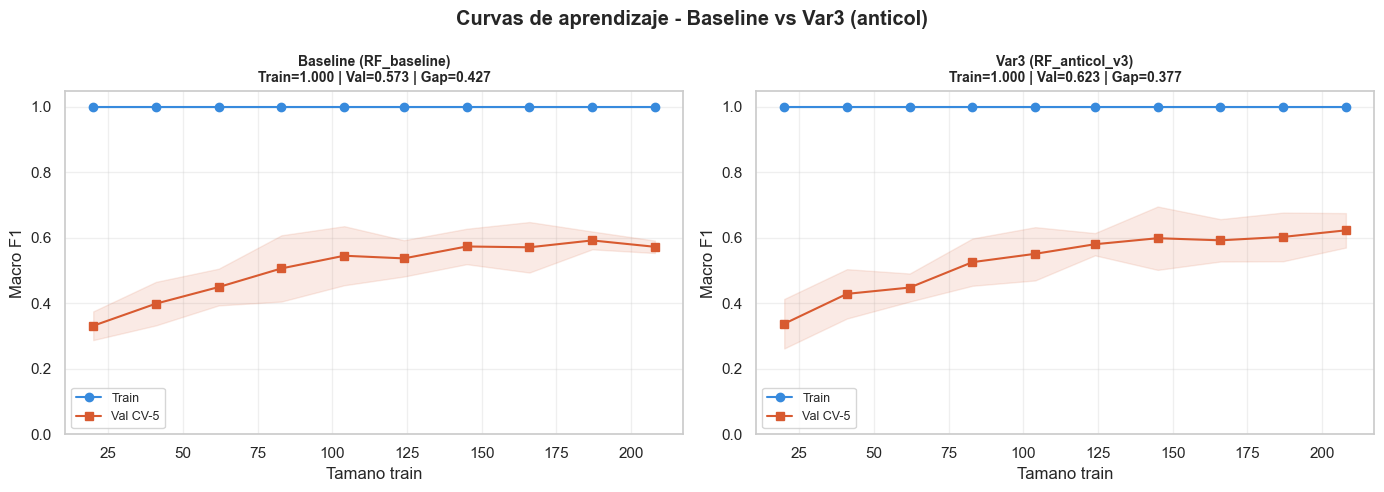

Gap referencia nb06 : 0.3418
Gap Baseline (hoy)  : 0.4274
Gap Var3            : 0.3771
Reduccion           : +0.0503 (+11.8%)
OK La eliminacion de colineales REDUJO el sobreajuste


In [8]:
train_sizes = np.linspace(0.10, 1.0, 10)
fig, axes   = plt.subplots(1, 2, figsize=(14, 5))
gaps = {}

for ax, (nombre, (pipe, X_tr, _)) in zip(axes, trained.items()):
    sizes, tr_sc, val_sc = learning_curve(
        clone(pipe), X_tr, y_train,
        train_sizes=train_sizes, cv=cv,
        scoring='f1_macro', n_jobs=-1,
        shuffle=True, random_state=RANDOM_STATE,
    )
    tr_m  = tr_sc.mean(axis=1);  tr_s  = tr_sc.std(axis=1)
    val_m = val_sc.mean(axis=1); val_s = val_sc.std(axis=1)
    gap   = tr_m[-1] - val_m[-1]
    gaps[nombre] = gap

    ax.plot(sizes, tr_m,  'o-', color='#378ADD', label='Train')
    ax.fill_between(sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='#378ADD')
    ax.plot(sizes, val_m, 's-', color='#D85A30', label='Val CV-5')
    ax.fill_between(sizes, val_m-val_s, val_m+val_s, alpha=0.12, color='#D85A30')
    ax.set_title(f'{nombre}\nTrain={tr_m[-1]:.3f} | Val={val_m[-1]:.3f} | Gap={gap:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Tamano train'); ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje - Baseline vs Var3 (anticol)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'var3_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

g_base = gaps.get('Baseline (RF_baseline)', 0)
g_var3 = gaps.get('Var3 (RF_anticol_v3)',  0)
red = g_base - g_var3
print(f'Gap referencia nb06 : 0.3418')
print(f'Gap Baseline (hoy)  : {g_base:.4f}')
print(f'Gap Var3            : {g_var3:.4f}')
print(f'Reduccion           : {red:+.4f} ({red/g_base*100:+.1f}%)')
if g_var3 < g_base:
    print('OK La eliminacion de colineales REDUJO el sobreajuste')
else:
    print('INFO Gap no mejoro - causa principal: n=326 insuficiente')


---
## PASO 8 - SHAP Var3: emergen las senales de colusion?

**Pregunta central:** Sin la colinealidad, aparecen `obra_cv_ofertas` y `obra_pct_montos_identicos` en el top SHAP de clase 3?

In [9]:
if not SHAP_OK:
    print('pip install shap')
else:
    def get_shap_top(pipe, X_te, clase=3, top_n=10):
        rf   = pipe.named_steps['model']
        prep = pipe.named_steps['prep']
        fnames = [n.replace('num__','').replace('cat__','')
                  for n in prep.get_feature_names_out()]
        X_prep = pd.DataFrame(prep.transform(X_te), columns=fnames)
        exp    = shap.TreeExplainer(rf)
        sv_out = exp.shap_values(X_prep)
        if isinstance(sv_out, np.ndarray) and sv_out.ndim == 3:
            sv = [sv_out[:,:,c] for c in range(sv_out.shape[2])]
        else:
            sv = sv_out
        mean_abs = np.abs(sv[clase]).mean(axis=0)
        return pd.Series(mean_abs, index=fnames).nlargest(top_n), sv, fnames, X_prep

    top_base, sv_base, fn_base, Xb = get_shap_top(
        trained['Baseline (RF_baseline)'][0], X_test)
    top_v3,   sv_v3,   fn_v3,   Xv = get_shap_top(
        trained['Var3 (RF_anticol_v3)'][0],   X_test_v3)

    print('TOP 10 SHAP CLASE 3 (Extrem. Riesgosa)')
    print('='*70)
    print(f'{"BASELINE":^33} | {"VAR3 (anticol)":^33}')
    print('-'*70)
    for i in range(10):
        b = f'{top_base.index[i][:28]:28s} {top_base.iloc[i]:.4f}'
        v = f'{top_v3.index[i][:28]:28s} {top_v3.iloc[i]:.4f}'
        print(f'{b} | {v}')

    SENALES = [
        'obra_cv_ofertas',
        'obra_pct_montos_identicos',
        'obra_rango_ofertas',
        'obra_pct_postores_igual_ganador',
        'obra_ratio_contractual_referencial',
        'obra_ratio_real_plan',
        'obra_sin_ejecucion',
    ]
    print('\nDIAGNOSTICO - SENALES DE COLUSION EN TOP 10 SHAP:')
    for s in SENALES:
        en_base = any(s in n for n in top_base.index)
        en_v3   = any(s in n for n in top_v3.index)
        if en_v3 and not en_base:
            estado = 'EMERGIO en Var3'
        elif en_v3 and en_base:
            estado = 'Mantiene en ambos'
        elif not en_v3 and en_base:
            estado = 'Desaparecio en Var3'
        else:
            estado = 'No aparece en ninguno'
        print(f'  {s:42s}: {estado}')


TOP 10 SHAP CLASE 3 (Extrem. Riesgosa)
            BASELINE              |          VAR3 (anticol)          
----------------------------------------------------------------------
obra_ctx_nivel_gobierno_GOBI 0.0206 | obra_ctx_nivel_gobierno_GOBI 0.0315
obra_n_miembros_comite       0.0178 | obra_ratio_repeticion_comite 0.0281
obra_n_procesos_comite       0.0177 | obra_n_convocatorias_comite  0.0254
obra_n_participantes_mean    0.0174 | obra_n_procesos_comite       0.0251
obra_n_dnis_comite_unicos    0.0167 | obra_n_participantes_mean    0.0210
obra_ctx_metodo_contratacion 0.0165 | TOTAL_CONTROL_SIMULTANEO     0.0194
obra_ratio_repeticion_comite 0.0146 | obra_n_participantes_max     0.0192
obra_n_convocatorias_comite  0.0143 | obra_monto_contractual_sum   0.0150
TOTAL_CONTROL_SIMULTANEO     0.0129 | obra_ratio_contractual_refer 0.0144
obra_n_participantes_max     0.0127 | obra_ctx_sector_OTROS        0.0139

DIAGNOSTICO - SENALES DE COLUSION EN TOP 10 SHAP:
  obra_cv_ofertas            

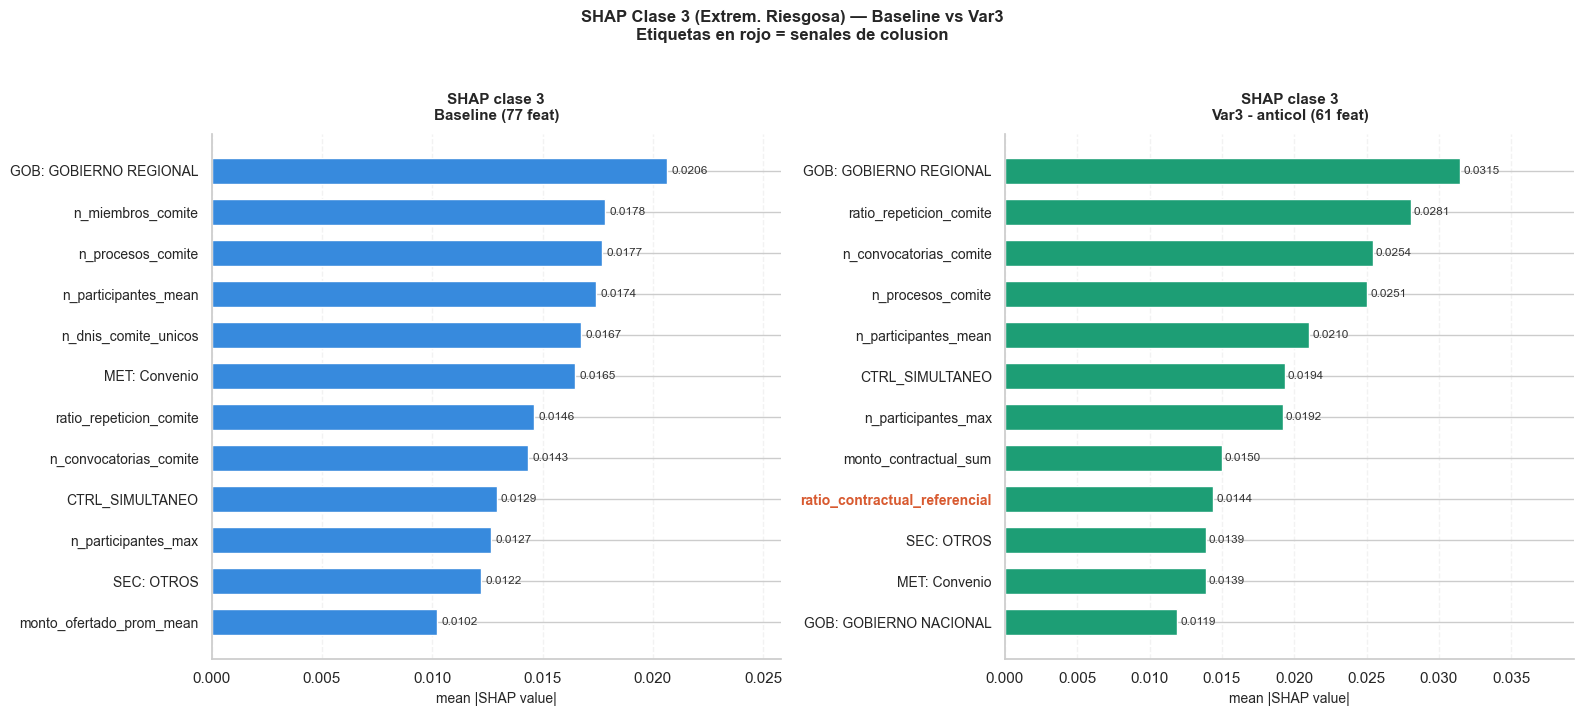

In [13]:
if SHAP_OK:
    # Extraer importancias medias por clase 3 para cada modelo
    mean_base = pd.Series(np.abs(sv_base[3]).mean(axis=0), index=fn_base).nlargest(12)
    mean_v3   = pd.Series(np.abs(sv_v3[3]).mean(axis=0),   index=fn_v3).nlargest(12)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
    fig.patch.set_facecolor("white")

    for ax, (titulo, datos, color) in zip(axes, [
        ("Baseline (77 feat)",       mean_base, "#378ADD"),
        ("Var3 - anticol (61 feat)", mean_v3,   "#1D9E75"),
    ]):
        # Ordenar de mayor a menor (barh va de abajo hacia arriba)
        datos_sorted = datos.sort_values(ascending=True)

        # Limpiar nombres: quitar prefijos largos
        labels = (datos_sorted.index
                  .str.replace("obra_ctx_nivel_gobierno_", "GOB: ", regex=False)
                  .str.replace("obra_ctx_metodo_contratacion_", "MET: ", regex=False)
                  .str.replace("obra_ctx_sector_", "SEC: ", regex=False)
                  .str.replace("obra_", "", regex=False)
                  .str.replace("TOTAL_CONTROL_", "CTRL_", regex=False))

        bars = ax.barh(range(len(datos_sorted)), datos_sorted.values,
                       color=color, edgecolor="white", height=0.65)

        # Valores al final de cada barra
        for i, (bar, val) in enumerate(zip(bars, datos_sorted.values)):
            ax.text(val + 0.0002, i, f"{val:.4f}",
                    va="center", ha="left", fontsize=8.5,
                    color="#333333")

        ax.set_yticks(range(len(datos_sorted)))
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel("mean |SHAP value|", fontsize=10)
        ax.set_title(f"SHAP clase 3\n{titulo}",
                     fontweight="bold", fontsize=11, pad=10)
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.25, linestyle="--")
        ax.set_xlim(0, datos_sorted.max() * 1.25)

    # Resaltar senales de colusion si aparecen
    SENALES = ["cv_ofertas", "pct_montos_identicos", "pct_postores",
               "ratio_contractual", "rango_ofertas"]
    for ax in axes:
        for label in ax.get_yticklabels():
            if any(s in label.get_text() for s in SENALES):
                label.set_color("#D85A30")
                label.set_fontweight("bold")

    plt.suptitle("SHAP Clase 3 (Extrem. Riesgosa) — Baseline vs Var3\n"
                 "Etiquetas en rojo = senales de colusion",
                 fontweight="bold", fontsize=12, y=1.02)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "var3_shap_comparison_clase3.png",
                dpi=300, bbox_inches="tight")
    plt.show()


---
## PASO 9 - Decision y conclusiones

In [12]:
base_f1 = [r['Macro F1'] for r in results if 'Baseline' in r['Experimento']][0]
var3_f1 = [r['Macro F1'] for r in results if 'Var3'     in r['Experimento']][0]
delta   = (var3_f1 - base_f1) / base_f1 * 100

print('='*65)
print('DECISION FINAL - Experimento Var3')
print('='*65)
print(f'  Baseline Macro F1 : {base_f1:.4f}')
print(f'  Var3     Macro F1 : {var3_f1:.4f}  ({delta:+.1f}%)')

if var3_f1 > base_f1 + 0.005:
    decision = 'ADOPTAR VAR3'
    razon = f'Eliminar colineales mejora Macro F1 en {delta:+.1f}%'
elif abs(delta) <= 0.005:
    decision = 'EQUIVALENTES - usar Var3 por parsimonia'
    razon = 'Mismas metricas con menos features. Principio de parsimonia.'
else:
    decision = 'MANTENER BASELINE'
    razon = 'La eliminacion de colineales no mejora el Macro F1.'

print(f'  DECISION : {decision}')
print(f'  RAZON    : {razon}')

print('\nINTERPRETACION SHAP:')
print('    la colinealidad aplastaba las senales. Usar anticol como base.')

print('\nPROXIMOS PASOS:')
print('  -> Regularizar RF (max_depth, min_samples_leaf)')
print('  -> Sprint 3: dataset empresa + funcionario (D4)')
print('  -> Repetir SHAP con dataset maestro enriquecido')

# Log
log_entry = {
    'timestamp':           datetime.now().isoformat(),
    'experimento':         'Var3 (RF_anticol_v3)',
    'cambio':              'Eliminar 16 features colineales VIF>10 / corr>0.85',
    'features_in':         X_train_v3.shape[1],
    'features_eliminadas': X_train.shape[1] - X_train_v3.shape[1],
    'macro_f1_holdout':    var3_f1,
    'macro_f1_baseline':   base_f1,
    'delta_pct':           round(delta, 2),
    'decision':            decision,
    'dataset':             'dataset_obra_v4_model.parquet',
    'target':              'y_riesgo_obra (4 niveles D1)',
}
log_path = LOG_DIR / 'metrics_experimentos.csv'
log_df   = pd.DataFrame([log_entry])
if log_path.exists():
    log_df = pd.concat([pd.read_csv(log_path), log_df], ignore_index=True)
log_df.to_csv(log_path, index=False, encoding='utf-8-sig')
print(f'\nOK Log actualizado: {log_path}')
display(pd.DataFrame([log_entry]))


DECISION FINAL - Experimento Var3
  Baseline Macro F1 : 0.5939
  Var3     Macro F1 : 0.6087  (+2.5%)
  DECISION : ADOPTAR VAR3
  RAZON    : Eliminar colineales mejora Macro F1 en +2.5%

INTERPRETACION SHAP:
    la colinealidad aplastaba las senales. Usar anticol como base.

PROXIMOS PASOS:
  -> Regularizar RF (max_depth, min_samples_leaf)
  -> Sprint 3: dataset empresa + funcionario (D4)
  -> Repetir SHAP con dataset maestro enriquecido

OK Log actualizado: C:\IA_Investigacion\Deteccion_Corrupcion\logs\metrics_experimentos.csv


,timestamp,experimento,cambio,features_in,features_eliminadas,macro_f1_holdout,macro_f1_baseline,delta_pct,decision,dataset,target
0,2026-05-29T18:45:28.345144,Var3 (RF_anticol_v3),Eliminar 16 features colineales VIF>10 / corr>...,61,16,0.6087,0.5939,2.5000,ADOPTAR VAR3,dataset_obra_v4_model.parquet,y_riesgo_obra (4 niveles D1)
